# Edge Detect

In [108]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

## Objective

We want to detect any edge in the image we define. We are defining a simple image where either a pixel is on or off (a pure black and white image) in this [notebook: conv.ipynb](./notebooks/conv.ipynb)
For this we need to train a kernel to perform this operation.

### Manual kernel definition

In [109]:
# Defining a kernel to detect edge on horizontal and vertical axis
# We will use the laplacian matrix as defined in "Theory of Edge Detection 1980" by Marr–Hildreth

laplacian = torch.Tensor([
    [ 0.0,  1.0,  0.0],
    [ 1.0, -4.0,  1.0],
    [ 0.0,  1.0,  0.0],
])

In [110]:
# Cross Correlation op

def corr2d(X: torch.Tensor, K: torch.Tensor) -> torch.Tensor:
    h, w = K.shape
    Y = torch.zeros(
        (X.shape[0] - h + 1, X.shape[1] - w + 1)
    )
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = (
                X[i: i + h, j: j + w] * K
            ).sum()
    return Y

torch.Size([512, 512])


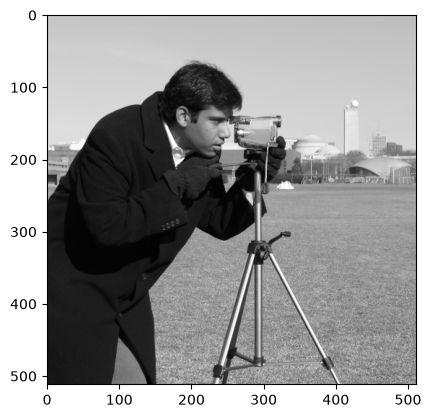

In [111]:
# Defining an image

from skimage import data

img = torch.tensor(
    data.camera(), dtype=torch.float32
)

# normalise the pixes 

img = img / 255.0

print(img.shape)

plt.imshow(img, cmap='gray')
plt.show()

In [112]:
edges = corr2d(img, laplacian)
edges.shape

torch.Size([510, 510])

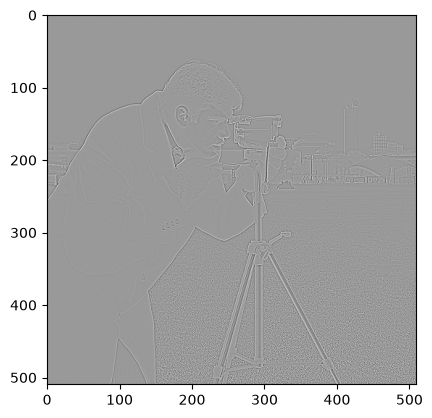

In [113]:
plt.imshow(edges, cmap='gray')
plt.show()

In [114]:
# Let's train a conv layer on this example

# Define the layer 

num_out_channels = 1

conv2d = nn.LazyConv2d(
    num_out_channels, kernel_size=(3, 3), bias = False
)

In [115]:
# train loop
# we are overfitting the layer to this example

X = img.reshape(1, 1, *img.shape)
Y = edges.reshape(1, 1, *edges.shape)

learning_rate = 0.01

epochs = 100

for i in range(epochs):
    Y_hat = conv2d(X)
    # squared loss
    loss = ((Y_hat - Y) ** 2).mean()
    conv2d.zero_grad()
    loss.backward()

    # back prop
    conv2d.weight.data[:] -= learning_rate * conv2d.weight.grad
    if (i + 1) % 10 == 0:
        print(f'epoch {i + 1}, loss {loss:.3f}')

epoch 10, loss 0.035
epoch 20, loss 0.021
epoch 30, loss 0.017
epoch 40, loss 0.015
epoch 50, loss 0.015
epoch 60, loss 0.015
epoch 70, loss 0.015
epoch 80, loss 0.015
epoch 90, loss 0.015
epoch 100, loss 0.015


In [116]:
# compare the kernels 

print(conv2d.weight.data.reshape(3, 3))
print(laplacian)

tensor([[ 0.2086, -0.2670,  0.2290],
        [-0.0384, -0.2835,  0.2002],
        [-0.2423,  0.0472,  0.1419]])
tensor([[ 0.,  1.,  0.],
        [ 1., -4.,  1.],
        [ 0.,  1.,  0.]])


In [117]:
# edge detection using learned kernel 
kernel = conv2d.weight.data.reshape(3, 3)
edges = corr2d(img, kernel)
edges.shape

torch.Size([510, 510])

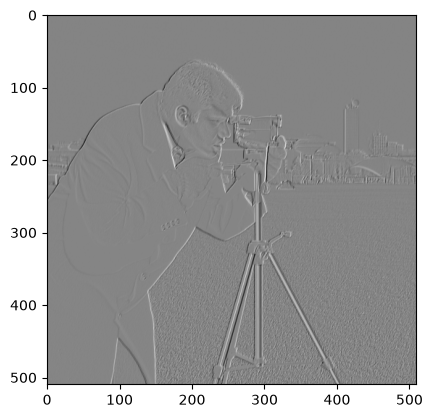

In [118]:
plt.imshow(edges, cmap='gray')
plt.show()